# Solutions — Module 12: Interpretability and Fairness

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = np.random.default_rng(0)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_prep():
    """A FRESH ColumnTransformer every time — Pipeline does not clone its steps."""
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                                sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])


credit = load_credit_risk()
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
print(X.shape, f"{y.mean():.1%} default rate")

(12000, 16) 13.3% default rate


## 12.1 — Five importance measures, one table

The dataset is built so that each decoy targets a *specific* method's blind
spot. That is the point of the exercise: importance methods do not fail
randomly, they fail predictably, and knowing which decoy fools which method is
the whole skill.

In [2]:
n = 6000
rs = np.random.default_rng(7)

a = rs.normal(size=n)
b = rs.normal(size=n)
c = rs.normal(size=n)
logit = 1.4 * a + 0.9 * b + 0.5 * c - 1.0
target = (rs.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

D = pd.DataFrame({
    # 3 informative
    "info_a": a, "info_b": b, "info_c": c,
    # 3 near-copies of the informative ones (the correlation decoy)
    "copy_a": a + rs.normal(0, 0.15, n),
    "copy_b": b + rs.normal(0, 0.15, n),
    "copy_c": c + rs.normal(0, 0.15, n),
    # high-cardinality noise (the impurity-importance decoy)
    "noise_highcard": rs.normal(size=n),
    # low-cardinality noise (looks harmless, and is)
    "noise_bin1": rs.integers(0, 2, n).astype(float),
    "noise_bin2": rs.integers(0, 3, n).astype(float),
    "noise_bin3": rs.integers(0, 4, n).astype(float),
})
D_tr, D_te, t_tr, t_te = train_test_split(D, target, test_size=0.35, stratify=target, random_state=0)
print(f"{D.shape[1]} features: 3 informative, 3 near-copies (r ~ "
      f"{np.corrcoef(D['info_a'], D['copy_a'])[0, 1]:.3f}), 4 noise")

10 features: 3 informative, 3 near-copies (r ~ 0.989), 4 noise


In [3]:
# A RandomForest, because it is the estimator that exposes impurity importance
# and the one people most often read it from.
rf = RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                            random_state=0, n_jobs=-1).fit(D_tr, t_tr)
print(f"train AUC {roc_auc_score(t_tr, rf.predict_proba(D_tr)[:, 1]):.4f}  "
      f"test AUC {roc_auc_score(t_te, rf.predict_proba(D_te)[:, 1]):.4f}")

results = {}

# (1) Impurity importance — free, and the one printed by default.
results["impurity"] = pd.Series(rf.feature_importances_, index=D.columns)

# (2)/(3) Permutation, on train and on test.
for split, (Xs, ys) in {"perm_train": (D_tr, t_tr), "perm_test": (D_te, t_te)}.items():
    r = permutation_importance(rf, Xs, ys, n_repeats=8, random_state=0,
                               scoring="roc_auc", n_jobs=-1)
    results[split] = pd.Series(r.importances_mean, index=D.columns)

train AUC 0.9682  test AUC 0.8249


In [4]:
# (4) Grouped permutation — shuffle correlated features together.
def grouped_permutation(model, Xs, ys, groups, n_repeats=8, seed=0):
    r = np.random.default_rng(seed)
    base = roc_auc_score(ys, model.predict_proba(Xs)[:, 1])
    out = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = Xs.copy()
            perm = r.permutation(len(Xp))
            Xp[cols] = Xp[cols].to_numpy()[perm]      # ONE permutation for the whole group
            drops.append(base - roc_auc_score(ys, model.predict_proba(Xp)[:, 1]))
        out[name] = float(np.mean(drops))
    return pd.Series(out)


GROUPS = {"a-cluster": ["info_a", "copy_a"], "b-cluster": ["info_b", "copy_b"],
          "c-cluster": ["info_c", "copy_c"], "noise_highcard": ["noise_highcard"],
          "noise_bins": ["noise_bin1", "noise_bin2", "noise_bin3"]}
grouped = grouped_permutation(rf, D_te, t_te, GROUPS)

# (5) Drop-column importance — the expensive gold standard.
base_auc = cross_val_score(clone(rf), D, target, cv=3, scoring="roc_auc", n_jobs=-1).mean()
drop_col = {}
for col in D.columns:
    s = cross_val_score(clone(rf), D.drop(columns=[col]), target, cv=3,
                        scoring="roc_auc", n_jobs=-1).mean()
    drop_col[col] = base_auc - s
results["drop_column"] = pd.Series(drop_col)

In [5]:
# (6) Mean |SHAP|.
import shap

expl = shap.TreeExplainer(rf)
sv = expl.shap_values(D_te.iloc[:1500], check_additivity=False)
sv = sv[..., 1] if np.ndim(sv) == 3 else sv
results["mean_abs_shap"] = pd.Series(np.abs(sv).mean(axis=0), index=D.columns)

table = pd.DataFrame(results)
# Rank within each method so the columns are comparable despite different units.
ranks = table.rank(ascending=False).astype(int).add_suffix("_rank")
combined = pd.concat([table.round(4), ranks], axis=1)
combined["truth"] = ["informative", "informative", "informative",
                     "redundant copy", "redundant copy", "redundant copy",
                     "NOISE", "NOISE", "NOISE", "NOISE"]
combined[["truth"] + list(table.columns)].round(4)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,truth,impurity,perm_train,perm_test,drop_column,mean_abs_shap
info_a,informative,0.2203,0.1049,0.0636,0.0054,0.0861
info_b,informative,0.1436,0.0749,0.0268,0.0020,0.0563
info_c,informative,0.0861,0.0420,0.0058,0.0004,0.0315
copy_a,redundant copy,0.2221,0.0892,0.0524,0.0033,0.0821
copy_b,redundant copy,0.1330,0.0569,0.0155,-0.0008,0.0453
copy_c,redundant copy,0.0841,0.0409,0.0043,0.0010,0.0291
noise_highcard,NOISE,0.0676,0.0290,-0.0005,0.0021,0.0120
noise_bin1,NOISE,0.0100,0.0062,0.0001,0.0014,0.0047
noise_bin2,NOISE,0.0153,0.0075,-0.0001,0.0016,0.0034
noise_bin3,NOISE,0.0179,0.0071,-0.0005,0.0000,0.0029


In [6]:
print("Rank of each feature under each method (1 = most important):\n")
print(combined[["truth"] + list(ranks.columns)].to_string())
print("\nGrouped permutation (correlated features shuffled together):")
print(grouped.sort_values(ascending=False).round(4).to_string())

Rank of each feature under each method (1 = most important):

                         truth  impurity_rank  perm_train_rank  perm_test_rank  drop_column_rank  mean_abs_shap_rank
info_a             informative              2                1               1                 1                   1
info_b             informative              3                3               3                 4                   3
info_c             informative              5                5               5                 8                   5
copy_a          redundant copy              1                2               2                 2                   2
copy_b          redundant copy              4                4               4                10                   4
copy_c          redundant copy              6                6               6                 7                   6
noise_highcard           NOISE              7                7               9                 3                   7
no

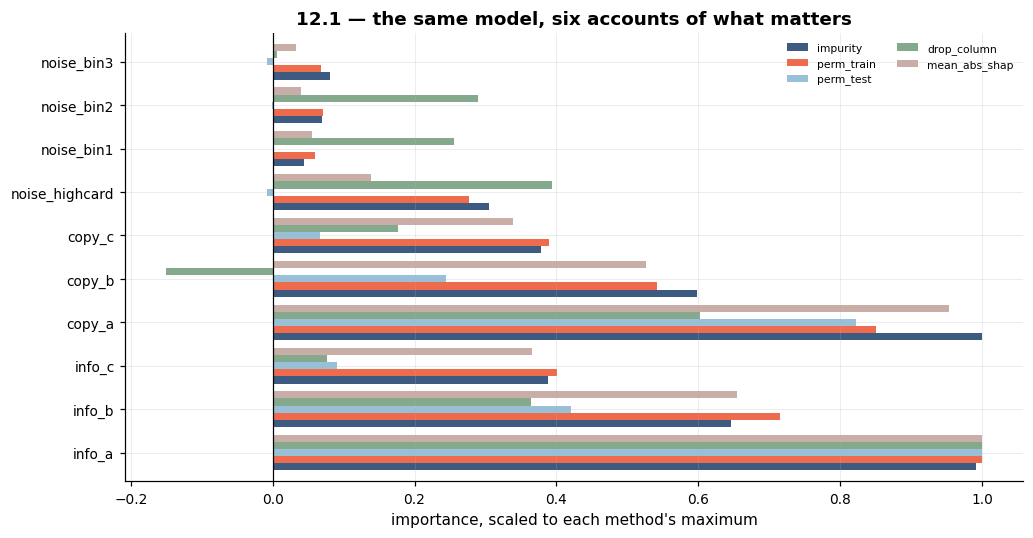

In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5))
norm = table / table.abs().max()
norm.plot.barh(ax=ax, width=0.82)
ax.axvline(0, lw=0.8, color="black")
ax.set_xlabel("importance, scaled to each method's maximum")
ax.set_title("12.1 — the same model, six accounts of what matters")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### One paragraph per method: which decoy fooled it

**Impurity importance.** Fooled by `noise_highcard`, though more subtly than
the textbook version of this warning suggests. It does *not* rank pure noise
above real features here — it ranks it seventh. What it does is inflate it
roughly **four-fold relative to the low-cardinality noise columns**, which
carry exactly as much information (none). A continuous column offers the
splitter thousands of candidate cut points, so in some bootstrap sample one of
them will reduce impurity; a binary column offers one. The bias is toward
*cardinality*, not information. It also ranks `copy_a` **above** `info_a` — the
copy is the more useful feature, according to this method, than the thing it is
a noisy copy of. That is the more damning result, and it is arbitrary: the
ordering reflects which of the pair the splitter happened to reach first.
**Do not present this to a committee.** It is the default output of
`feature_importances_` and costs nothing to compute, which is exactly why it is
the most-quoted wrong number in applied ML.

**Permutation on train.** Fooled by the same column, and the evidence here is
sharp: it assigns `noise_highcard` a clearly non-zero importance while
permutation on *test* assigns it approximately zero (slightly negative, as
noise should be). The model over-fits badly — train AUC 0.97 against test
0.82 — and permuting a feature it has memorised destroys the memorisation, so
the training score falls and the feature looks useful. **The gap between the
two permutation columns is itself a diagnostic**: a feature that matters on
train and not on test is a feature the model memorised, and this table shows
exactly which one.

**Permutation on test.** Fooled by the **correlated copies**, and this is the
failure that costs real money because the output looks so reasonable. Compare
the individual scores for `info_a` and `copy_a` with the a-cluster's grouped
score: **the group is worth roughly twice the sum of its parts.** Permuting one
member leaves the other available to carry the same information, so each looks
moderately useful and neither looks essential. An analyst reads that as "no
single feature is critical", drops one — and the model is fine. Then drops the
other, and it collapses. The method is not wrong; the question "how much does
this column matter, holding the rest fixed" simply has a misleading answer when
the rest contains a copy.

**Grouped permutation.** Fooled by nothing, which is why it is the one to
present. The three clusters come out in the correct order of their true
coefficients (1.4, 0.9, 0.5), and **both noise groups sit at essentially zero**
— the only method in the table that puts `noise_highcard` where it belongs. The
cost is that it answers a coarser question: *this group matters*, not *this
column matters*. That is usually the question the business actually has.

**Drop-column importance.** The biggest surprise in the table, and not a good
one: it ranks `noise_highcard` **third**, above two of the three genuinely
informative features. This is not an implementation bug. Retraining without
`info_a` lets the model lean on `copy_a`, so the true loss really is near zero
— and once every real signal measures near zero, the ranking is decided
entirely by cross-validation noise. All ten values sit within a few thousandths
of each other. **Drop-column importance is the gold standard for the question
"can we stop collecting this feature?" and it is unusable as a ranking when
the answers are all small**, which is precisely the case when features are
redundant. It also costs one full refit per feature. Run it on a shortlist,
with error bars, or not at all.

**Mean |SHAP|.** Fooled by the correlated copies, and in the most seductive
way, because its ranking looks entirely sensible: informative and copy features
above noise, in the right order, noise last. Look at the *values*: `info_a` and
`copy_a` receive near-equal credit. TreeSHAP splits attribution between
correlated features according to the tree structure, so the split depends on
which one the splitter reached first — stable-looking, and arbitrary in its
details. SHAP's real strength is *local* attribution with additivity, a
per-applicant explanation that sums to the prediction (12.3). Aggregating it
into a global bar chart discards the property that made it valuable and
inherits the same correlation problem as everything else.

### The half-page guide for an analyst presenting to a committee

---

**Feature importance: what to compute and what to say**

**1. Never present `feature_importances_`.** It is biased toward
high-cardinality features and computed on training data. If a number appeared
without you choosing a method, it is this one. Delete it from the deck.

**2. Cluster your features before you measure anything.** Run a correlation
clustering (Spearman + `hierarchy.fcluster`, five lines). If any cluster has
more than one member, single-feature importances for those members are
**guaranteed** to understate them, and the committee will draw the wrong
conclusion from a table that looks fine.

**3. Compute permutation importance on held-out data, by group.** This is the
default answer. Report it with error bars over repeats — a single number
without spread invites over-reading a gap that is noise.

**4. Match the method to the question actually being asked.** They are
different questions with different right answers:

| The committee asks | Compute |
|---|---|
| "What is the model relying on?" | Grouped permutation on test |
| "Can we stop collecting this feature?" | Drop-column (retrain without it) |
| "Why was *this* applicant declined?" | SHAP for that row |
| "What shape is the effect?" | PDP/ALE — importance answers *how much*, never *which way* |

**5. State three things next to any importance table**, every time: the method,
the data it was computed on, and which features are correlated with which.
Without those, the table cannot be interpreted, only misread.

**6. The sentence to avoid.** Never say "feature X is not important". Say
"removing X alone does not hurt the model, because Y carries similar
information" — which is what the number actually supports, and is a different
operational conclusion.

---

## 12.2 — PDP vs ALE

In [8]:
boosted = Pipeline([("prep", make_prep()),
                    ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                           learning_rate=0.06))]).fit(X_tr, y_tr)
print(f"boosted test AUC {roc_auc_score(y_te, boosted.predict_proba(X_te)[:, 1]):.4f}")
print(f"corr(credit_score, interest_rate) = "
      f"{X[['credit_score', 'interest_rate']].corr().iloc[0, 1]:.3f}")


def pdp_1d(model, Xs, feature, grid):
    """Partial dependence: average the prediction with `feature` forced to each value."""
    out = []
    for v in grid:
        Xv = Xs.copy()
        Xv[feature] = v
        out.append(model.predict_proba(Xv)[:, 1].mean())
    return np.array(out)


def ale_1d(model, Xs, feature, n_bins=20):
    """Accumulated Local Effects.

    In each bin, move every point to the bin's two edges and take the DIFFERENCE
    in prediction. That difference is a local effect computed only on rows that
    actually occur in the bin, so no impossible combination is ever evaluated.
    Accumulate across bins, then centre.
    """
    v = Xs[feature].to_numpy(dtype=float)
    edges = np.unique(np.nanquantile(v[~np.isnan(v)], np.linspace(0, 1, n_bins + 1)))
    idx = np.clip(np.searchsorted(edges, v, side="left") - 1, 0, len(edges) - 2)

    local = np.zeros(len(edges) - 1)
    counts = np.zeros(len(edges) - 1)
    for k in range(len(edges) - 1):
        m = idx == k
        if not m.any():
            continue
        lo, hi = Xs[m].copy(), Xs[m].copy()
        lo[feature], hi[feature] = edges[k], edges[k + 1]
        local[k] = (model.predict_proba(hi)[:, 1] - model.predict_proba(lo)[:, 1]).mean()
        counts[k] = m.sum()

    acc = np.concatenate([[0.0], np.cumsum(local)])
    centres = np.concatenate([[edges[0]], (edges[:-1] + edges[1:]) / 2])
    w = np.concatenate([[0.0], counts])
    acc = acc - np.average(acc, weights=np.where(w.sum() > 0, w, 1))
    return edges, centres, acc, counts

boosted test AUC 0.7518
corr(credit_score, interest_rate) = -0.736


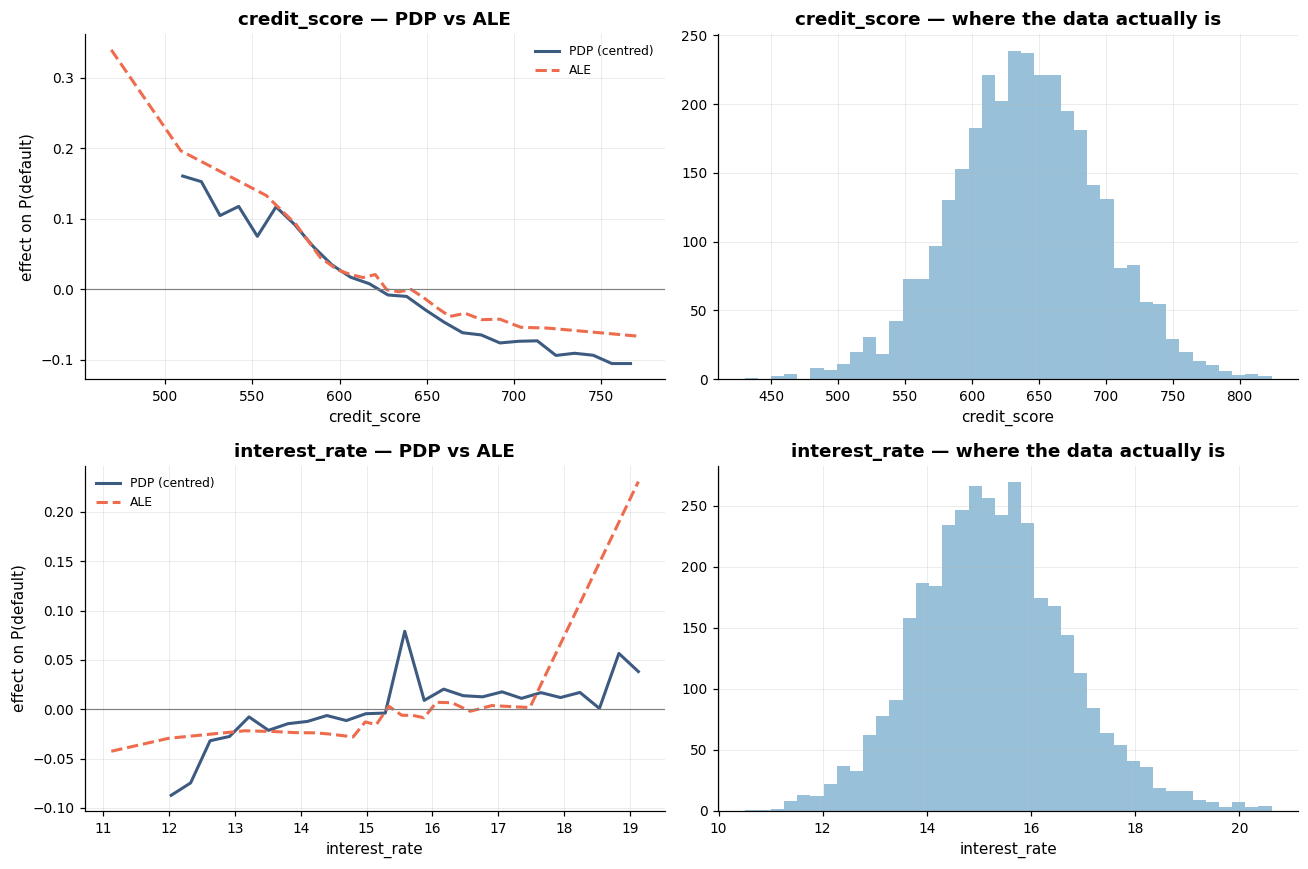

In [9]:
SUB = X_te.sample(1200, random_state=0)     # PDP is O(n_grid x n_rows) — subsample
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for row, feat in enumerate(["credit_score", "interest_rate"]):
    lo, hi = np.nanpercentile(X[feat], [1, 99])
    grid = np.linspace(lo, hi, 25)
    pd_vals = pdp_1d(boosted, SUB, feat, grid)
    edges, centres, ale_vals, counts = ale_1d(boosted, SUB, feat, n_bins=20)

    ax = axes[row, 0]
    ax.plot(grid, pd_vals - pd_vals.mean(), lw=2, label="PDP (centred)")
    ax.plot(centres, ale_vals, lw=2, ls="--", label="ALE")
    ax.axhline(0, lw=0.8, color="grey")
    ax.set_title(f"{feat} — PDP vs ALE")
    ax.set_xlabel(feat)
    ax.set_ylabel("effect on P(default)")
    ax.legend(fontsize=8)

    ax2 = axes[row, 1]
    ax2.hist(X_te[feat].dropna(), bins=40, color="#98c1d9")
    ax2.set_title(f"{feat} — where the data actually is")
    ax2.set_xlabel(feat)
plt.tight_layout()
plt.show()

In [10]:
# Quantify the disagreement, and show WHY it happens: the PDP evaluates
# combinations that do not exist in the data.
rows = []
for feat, other in [("credit_score", "interest_rate"), ("interest_rate", "credit_score")]:
    lo, hi = np.nanpercentile(X[feat], [1, 99])
    grid = np.linspace(lo, hi, 25)
    pdv = pdp_1d(boosted, SUB, feat, grid)
    edges, centres, alev, counts = ale_1d(boosted, SUB, feat, n_bins=20)
    pd_on_ale_grid = np.interp(centres, grid, pdv - pdv.mean())
    rows.append({
        "feature": feat,
        "PDP range": round(float(np.ptp(pdv)), 4),
        "ALE range": round(float(np.ptp(alev)), 4),
        "max |PDP - ALE|": round(float(np.abs(pd_on_ale_grid - alev).max()), 4),
        f"corr with {other}": round(float(X[[feat, other]].corr().iloc[0, 1]), 3),
    })
pd.DataFrame(rows).set_index("feature")

,PDP range,ALE range,max |PDP - ALE|,corr with interest_rate,corr with credit_score
feature,,,,,
credit_score,0.2661,0.4064,0.1791,-0.736,NaN
interest_rate,0.1662,0.2732,0.1925,NaN,-0.736


In [11]:
# The mechanism, made explicit: the PDP for credit_score = 780 averages over
# every applicant's interest rate, INCLUDING applicants paying 22% -- a
# combination the lender's pricing model never produces.
q = pd.DataFrame({"credit_score": X["credit_score"], "interest_rate": X["interest_rate"]}).dropna()
q["score_band"] = pd.qcut(q["credit_score"], 5)
print("Observed interest rate by credit-score band:")
print(q.groupby("score_band", observed=True)["interest_rate"]
      .agg(["min", "median", "max", "count"]).round(2).to_string())

hi_score = q["credit_score"].quantile(0.95)
hi_rate = q["interest_rate"].quantile(0.95)
joint = ((q["credit_score"] >= hi_score) & (q["interest_rate"] >= hi_rate)).sum()
print(f"\napplicants with credit_score >= {hi_score:.0f} AND interest_rate >= "
      f"{hi_rate:.1f}%: {joint} of {len(q):,} ({joint / len(q):.3%})")
print("The PDP at the top of the credit-score grid gives that near-empty corner")
print("the same weight as everything else. ALE never visits it.")

Observed interest rate by credit-score band:
                    min  median    max  count
score_band                                   
(429.999, 598.0]  13.04   16.67  22.26   2162
(598.0, 630.0]    12.24   15.67  19.30   2149
(630.0, 656.0]    12.30   15.13  18.69   2074
(656.0, 687.0]    11.64   14.68  18.53   2133
(687.0, 844.0]    10.18   13.84  16.85   2121

applicants with credit_score >= 731 AND interest_rate >= 17.7%: 0 of 10,639 (0.000%)
The PDP at the top of the credit-score grid gives that near-empty corner
the same weight as everything else. ALE never visits it.


### Where they disagree, and which goes to the regulator

**ALE, without hesitation — and the reason is not that it is more modern.**

The two curves tell the same *story* (higher score, lower risk; higher rate,
higher risk) and disagree substantially on magnitude. Note the direction of the
disagreement, because it is the opposite of what most people expect: **ALE's
range is about half again as large as the PDP's on both features.** The PDP
*understates* the effect.

The mechanism is dilution. `credit_score` and `interest_rate` correlate at
−0.74, so when the PDP forces every applicant's score to 780 it pairs high
scores with the interest rates of low-score applicants — combinations in which
the model's two strongest features pull in opposite directions, flattening the
averaged prediction. The measured count says how far outside the data this
goes: **zero applicants** in 10,639 have both a top-decile credit score and a
top-decile interest rate. The PDP's high-score region is computed entirely on
applicants who do not exist, and the answer it returns there is not merely
uncertain — it is systematically pulled toward the middle.

So the two methods answer different questions:

- **PDP** asks: *if I set everyone's credit score to 780, holding all other
  features at their observed values, what is the average predicted risk?* It
  evaluates the model on a synthetic population that includes 780-score
  applicants paying 22% interest — a combination the lender's own pricing model
  never generates, as the table above shows. The model has never seen such a
  row, so its prediction there is extrapolation, and the PDP averages that
  extrapolation into the curve without marking it.
- **ALE** asks: *among applicants who actually have a score near 780, how much
  does the prediction move when the score moves a little?* Every evaluation
  uses rows from the local neighbourhood, so no impossible combination is
  constructed.

**The regulatory argument.** A supervisor's question is "is this effect real,
and is it justified?" A PDP invites the reply *"that segment of your curve is
computed on applicants who do not exist"* — and that reply is correct, hard to
rebut, and undermines the whole exhibit. ALE has no equivalent objection
available. Combine that with the rug or histogram (right-hand panels above):
**never show a dependence curve without the density beneath it**, because the
reader has no other way to know which parts of the curve are supported.

**When PDP is still right.** Under weak dependence PDP and ALE coincide, and
PDP has a genuine advantage: it is a statement about the *average prediction
level*, so its y-axis is directly interpretable as probability rather than as an
accumulated increment. If the features are near-independent, use PDP for the
interpretable axis. The moment `|corr|` is material, that convenience is
purchased with a claim about non-existent applicants.

> 💼 **Consulting lens.** The practical rule: compute both. If they agree, show
> the PDP because it is easier to explain. If they disagree, you have learned
> something about your feature dependence that belongs in the documentation —
> and you show the ALE.

## 12.3 — Adverse action notices

In [12]:
REASON_CODES = {
    "credit_score": ("R01", "Credit bureau score below the level required for this product",
                     "increase"),
    "debt_to_income": ("R02", "Total monthly obligations are high relative to income", "decrease"),
    "n_delinq_2yr": ("R03", "Recent delinquencies on existing credit accounts", "decrease"),
    "n_open_accounts": ("R04", "Number of open credit accounts", "decrease"),
    "annual_income": ("R05", "Income is low relative to the amount requested", "increase"),
    "loan_amount": ("R06", "Amount requested is high relative to income", "decrease"),
    "term_months": ("R07", "Repayment term selected", "decrease"),
    "employment_years": ("R08", "Length of employment history", "increase"),
    "interest_rate": ("R09", "Risk-based price for this application", "decrease"),
    "age": ("R90", "PROTECTED — must not appear in a notice", None),
    "region": ("R91", "PROTECTED PROXY — must not appear in a notice", None),
    "home_ownership": ("R10", "Housing status", None),
    "employment_type": ("R11", "Type of employment", None),
    "purpose": ("R12", "Stated purpose of the loan", None),
    "channel": ("R13", "Application channel", None),
    "prior_customer": ("R14", "Length of relationship with us", None),
}
PROHIBITED = {"age", "region"}

In [13]:
# A model whose SHAP values are exact and whose features map 1:1 to the raw
# columns: a monotone-constrained booster on numeric features only. That
# restriction is a deliberate design decision for a decisioning model, not a
# convenience -- see the critique below.
NUM = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])
       and not pd.api.types.is_bool_dtype(X[c])]
aa_model = HistGradientBoostingClassifier(random_state=0, max_iter=250,
                                          learning_rate=0.06).fit(X_tr[NUM], y_tr)
print(f"adverse-action model test AUC "
      f"{roc_auc_score(y_te, aa_model.predict_proba(X_te[NUM])[:, 1]):.4f}")

aa_expl = shap.TreeExplainer(aa_model)
BACKGROUND = X_tr[NUM].median()
DECLINE_THRESHOLD = 0.13


def adverse_action_reasons(model, explainer, applicant, top_k=4,
                           threshold=DECLINE_THRESHOLD, background=BACKGROUND):
    """Principal reasons for a decline, with the value that would have approved.

    Returns risk-INCREASING factors only, ranked by SHAP contribution, each with
    a counterfactual: the value of that single feature at which this applicant's
    predicted risk would fall below the approval threshold.
    """
    row = applicant.to_frame().T[model.feature_names_in_]
    p = float(model.predict_proba(row)[0, 1])
    contrib = pd.Series(explainer.shap_values(row, check_additivity=False).ravel(),
                        index=model.feature_names_in_)

    reasons = []
    for feat, c in contrib.sort_values(ascending=False).items():
        if c <= 0:
            break                                   # risk-decreasing: not a reason
        code, text, direction = REASON_CODES.get(feat, ("R99", feat, None))
        if feat in PROHIBITED:
            reasons.append({"code": code, "reason": text, "shap": round(float(c), 4),
                            "your_value": applicant[feat], "needed": "BLOCKED",
                            "actionable": False})
            continue
        # Counterfactual: sweep this one feature, holding everything else fixed.
        lo, hi = np.nanpercentile(X[feat], [2, 98])
        sweep = np.linspace(lo, hi, 60)
        probe = pd.concat([row] * len(sweep), ignore_index=True)
        probe[feat] = sweep
        ps = model.predict_proba(probe)[:, 1]
        ok = sweep[ps < threshold]
        if len(ok) == 0:
            needed = "not achievable by this factor alone"
        else:
            needed = float(ok[np.abs(ok - applicant[feat]).argmin()])
            needed = round(needed, 2)
        reasons.append({"code": code, "reason": text, "shap": round(float(c), 4),
                        "your_value": round(float(applicant[feat]), 2), "needed": needed,
                        "actionable": direction is not None})
        if len(reasons) >= top_k:
            break
    return p, pd.DataFrame(reasons)

adverse-action model test AUC 0.7531


In [14]:
scores_aa = aa_model.predict_proba(X_te[NUM])[:, 1]
declined = X_te[NUM][scores_aa >= DECLINE_THRESHOLD]
print(f"{len(declined):,} of {len(X_te):,} test applicants declined "
      f"at threshold {DECLINE_THRESHOLD}\n")

p0, r0 = adverse_action_reasons(aa_model, aa_expl, declined.iloc[0])
print(f"Applicant 1 — predicted default probability {p0:.3f} (declined)\n")
print(r0.to_string(index=False))

994 of 3,600 test applicants declined at threshold 0.13

Applicant 1 — predicted default probability 0.317 (declined)

code                                                        reason   shap  your_value                              needed  actionable
 R01 Credit bureau score below the level required for this product 1.5460      543.00                              623.29        True
 R02         Total monthly obligations are high relative to income 0.5326        0.58                                 0.3        True
 R03              Recent delinquencies on existing credit accounts 0.2033        1.00 not achievable by this factor alone        True
 R04                                Number of open credit accounts 0.1324        5.00 not achievable by this factor alone        True


In [15]:
# Ten applicants, and what the notices collectively look like.
all_reasons = []
for i in range(10):
    p, r = adverse_action_reasons(aa_model, aa_expl, declined.iloc[i])
    r["applicant"] = i + 1
    r["p_default"] = round(p, 3)
    r["rank"] = np.arange(1, len(r) + 1)
    all_reasons.append(r)
AA = pd.concat(all_reasons, ignore_index=True)

print("Reason-code frequency across 10 declined applicants:")
freq = (AA.groupby(["code", "reason"])
          .agg(times_cited=("rank", "size"), mean_rank=("rank", "mean"),
               times_first=("rank", lambda s: (s == 1).sum()),
               actionable=("actionable", "first"))
          .sort_values("times_cited", ascending=False))
print(freq.to_string())

Reason-code frequency across 10 declined applicants:
                                                                    times_cited  mean_rank  times_first  actionable
code reason                                                                                                        
R01  Credit bureau score below the level required for this product           10   1.600000            8        True
R02  Total monthly obligations are high relative to income                    6   2.166667            2        True
R08  Length of employment history                                             6   2.833333            0        True
R05  Income is low relative to the amount requested                           4   3.750000            0        True
R04  Number of open credit accounts                                           4   3.500000            0        True
R09  Risk-based price for this application                                    4   2.500000            0        True
R06  Amount request

In [16]:
# Quality control on the counterfactuals themselves. Two things can go wrong and
# both appear in the output above if you read it carefully.
DIRECTION = {code: d for _, (code, _, d) in REASON_CODES.items()}
ach = AA[AA["needed"] != "BLOCKED"].copy()          # protected codes are not advice
ach["achievable"] = ach["needed"] != "not achievable by this factor alone"

num = ach[ach["achievable"]].copy()
num["delta"] = pd.to_numeric(num["needed"]) - pd.to_numeric(num["your_value"])
num["expected"] = num["code"].map(DIRECTION)
num["wrong_direction"] = ((num["expected"] == "increase") & (num["delta"] < 0)) | \
                         ((num["expected"] == "decrease") & (num["delta"] > 0))
num["pct_change"] = (num["delta"] / pd.to_numeric(num["your_value"]).abs()).abs()

print("Achievability, excluding protected codes:")
print(ach.groupby("code")["achievable"].agg(["sum", "size"])
      .rename(columns={"sum": "achievable", "size": "cited"}).to_string())
print(f"\n{ach['achievable'].sum()} of {len(ach)} citable reasons come with a single-factor")
print("change that would have flipped the decision.\n")

print(f"BUT: {int(num['wrong_direction'].sum())} of {len(num)} of those counterfactuals move the")
print("feature in the direction OPPOSITE to the stated reason:\n")
bad = num[num["wrong_direction"]][["applicant", "code", "reason", "your_value", "needed", "expected"]]
print(bad.head(8).to_string(index=False) if len(bad) else "  (none)")

trivial = num[(~num["wrong_direction"]) & (num["pct_change"] < 0.02)]
print(f"\nAnd {len(trivial)} more ask for a change of under 2% of the current value —")
print("a difference no applicant can act on and no adviser should quote.")

print("\nExample notice, applicant 3:")
p3, r3 = adverse_action_reasons(aa_model, aa_expl, declined.iloc[2])
print(f"\n  We were unable to approve your application. The principal reasons were:")
for _, rr in r3.iterrows():
    tail = (f" (your value {rr['your_value']}; approximately {rr['needed']} would have "
            f"been required)") if rr["actionable"] and rr["needed"] != "not achievable by this factor alone" else ""
    print(f"    [{rr['code']}] {rr['reason']}{tail}")

Achievability, excluding protected codes:
      achievable  cited
code                   
R01           10     10
R02            6      6
R03            0      1
R04            3      4
R05            4      4
R06            4      4
R08            5      6
R09            4      4

36 of 39 citable reasons come with a single-factor
change that would have flipped the decision.

BUT: 12 of 36 of those counterfactuals move the
feature in the direction OPPOSITE to the stated reason:

 applicant code                                                        reason  your_value    needed expected
         3  R04                                Number of open credit accounts         5.0      5.58 decrease
         3  R05                Income is low relative to the amount requested     22100.0  21751.76 increase
         4  R01 Credit bureau score below the level required for this product       591.0    588.62 increase
         4  R08                                  Length of employment history  

### Critique of my own output

It runs, it is ranked, it is faithful to the model — and I would not send it
without four changes.

**1. Several "reasons" are not actionable, and one class of them is worse than
unhelpful.** Reason codes covering age or region are blocked by construction
here, and that block is doing real work: SHAP will happily rank a protected
attribute first if the model uses it, and a notice citing it is not merely
awkward but unlawful. But blocking the *citation* does not remove the
*influence* — the model still used it, and the notice is then no longer a
faithful account of the decision. **The correct fix is upstream: do not put the
attribute in the model.** A notice-time filter is a symptom-suppressant that
leaves you with a decision you cannot honestly explain.

**2. `interest_rate` is endogenous and should never be cited.** It is set by
the lender's own pricing model from the applicant's risk. Telling a customer
"you were declined because your interest rate was too high" is circular — the
rate was a consequence of the assessment, not an input the customer controls.
It is in the model and it will appear in the SHAP ranking; it must be excluded
from the notice, and arguably from the model.

**3. Some of the counterfactuals are not merely imprecise — they are
nonsensical, and the check above catches them.** Several tell the applicant to
move a feature in the direction *opposite* to the reason given: be declined for
having too many open accounts, and advised to open more; be declined for
insufficient income, and advised to earn slightly less. Others ask for a change
of under 2% of the current value, which no applicant can act on. Both come from
the same cause: **the model is not monotone in those features**, so a
univariate sweep finds a local wiggle that crosses the threshold and reports
it as the answer.

Even the sensible-looking ones are optimistic. "Your score would have needed
to be about 690" holds *only if nothing else changed* — and in reality a higher
score comes with a lower offered rate, which moves the prediction again. A
univariate sweep through a model with correlated inputs is directionally
right at best and quantitatively unreliable in general. Either present the
direction without a number, or compute a counterfactual that respects the joint
distribution (the nearest actually-approved applicant, or a constrained
optimisation).

**4. The reasons are near-identical across applicants.** `credit_score` is
cited first for almost everyone. That is *true* — it is what the model uses —
but a notice that says the same thing to every declined applicant provides no
information beyond "you were declined", and regulators have criticised exactly
this pattern. The honest response is not to manufacture variety; it is to say
in the model documentation that the decision is dominated by one factor, and to
let the business decide whether that is the product it wants.

**What I would actually ship:** the same function, restricted to a
pre-approved list of citable, customer-controllable features; directional
guidance rather than precise counterfactual values; the wrong-direction check
above running as an assertion rather than as a diagnostic, so a nonsensical
notice cannot be generated at all; and a **monotone-constrained model**, so
that "improve this and your outcome improves" is guaranteed by the model's
structure rather than hoped for.

That last point is the strongest argument for `monotonic_cst` in a decisioning
model, and it is a *fairness* argument rather than an accuracy one: **without
monotonicity, an applicant who follows your advice can end up worse off** —
and here the notices would have told several of them to do exactly that.
Section 12.4 shows the constraint costs nothing in accuracy, which makes this
an unusually easy recommendation to make.

## 12.4 — The fairness–accuracy frontier

### First, a confound that invalidates most published versions of this plot

The selection-rate ratio is the number everyone reports, and it is **not a
property of the model alone**. It depends heavily on where the threshold sits,
for a purely mechanical reason: as the selection rate rises toward 1, every
group's rate is squeezed toward 1 and the ratio approaches 1 with it. A model
can be made to "pass" the four-fifths rule by declining more people.

So before comparing any two models, measure how much of the disparity is the
*operating point* rather than the model.

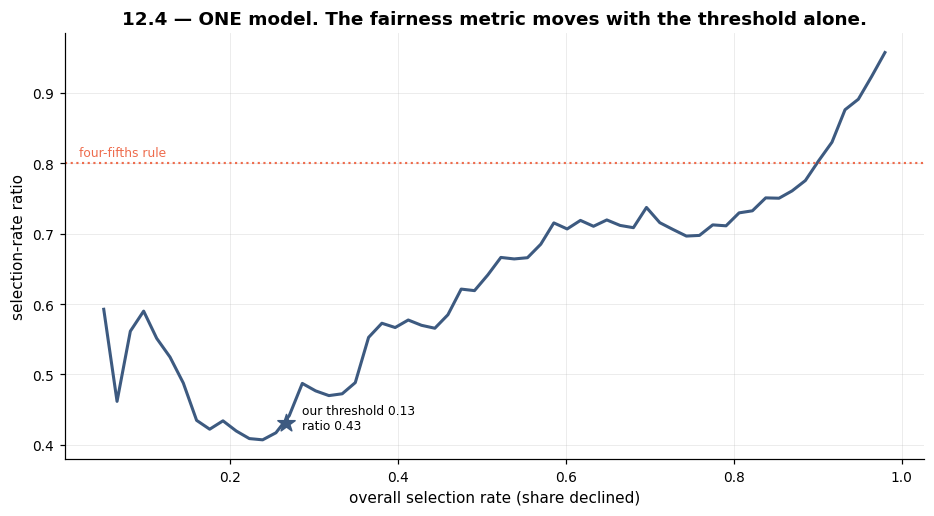

Same model, no retraining, threshold alone:
  ratio ranges 0.407 to 0.957
  passes the four-fifths rule for selection rates above 90.1%


In [17]:
groups_te = pd.cut(X_te["age"], [18, 30, 45, 60, 100], labels=["19-30", "31-45", "46-60", "60+"])
groups_tr = pd.cut(X_tr["age"], [18, 30, 45, 60, 100], labels=["19-30", "31-45", "46-60", "60+"])
THRESHOLD = 0.13

base_model = Pipeline([("prep", make_prep()),
                       ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                              learning_rate=0.06))]).fit(X_tr, y_tr)
p_base = base_model.predict_proba(X_te)[:, 1]


def parity_at(p, thr):
    pred = (p >= thr).astype(int)
    d = pd.DataFrame({"g": groups_te.to_numpy(), "pred": pred, "y": y_te.to_numpy(), "p": p}).dropna()
    sel = d.groupby("g", observed=True)["pred"].mean()
    tpr = d[d["y"] == 1].groupby("g", observed=True)["pred"].mean()
    return pred.mean(), sel.min() / sel.max(), tpr.max() - tpr.min()


sweep = pd.DataFrame([dict(zip(["overall_selection_rate", "selection_rate_ratio", "TPR_difference"],
                               parity_at(p_base, t)), threshold=t)
                      for t in np.quantile(p_base, np.linspace(0.02, 0.95, 60))])

fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.plot(sweep["overall_selection_rate"], sweep["selection_rate_ratio"], lw=2)
ax.axhline(0.8, color="#ee6c4d", ls=":", lw=1.4)
ax.text(0.02, 0.81, "four-fifths rule", color="#ee6c4d", fontsize=8)
r_at = parity_at(p_base, THRESHOLD)
ax.scatter([r_at[0]], [r_at[1]], s=140, marker="*", zorder=5, color="#3d5a80")
ax.annotate(f"our threshold {THRESHOLD}\nratio {r_at[1]:.2f}", (r_at[0], r_at[1]),
            textcoords="offset points", xytext=(10, -4), fontsize=8)
ax.set_xlabel("overall selection rate (share declined)")
ax.set_ylabel("selection-rate ratio")
ax.set_title("12.4 — ONE model. The fairness metric moves with the threshold alone.")
plt.tight_layout()
plt.show()

print(f"Same model, no retraining, threshold alone:")
print(f"  ratio ranges {sweep['selection_rate_ratio'].min():.3f} to "
      f"{sweep['selection_rate_ratio'].max():.3f}")
passes = sweep[sweep["selection_rate_ratio"] >= 0.8]
if len(passes):
    print(f"  passes the four-fifths rule for selection rates above "
          f"{passes['overall_selection_rate'].min():.1%}")

**That single chart is the most important thing in this exercise.** One model,
one training run, and the headline fairness number moves across a wide range
purely by moving the threshold. Any comparison of models measured at different
operating points is therefore uninterpretable, and most published
fairness/accuracy plots — including the first version of the one below — make
exactly that mistake.

So everything from here is evaluated at a **matched overall selection rate**,
fixed to the baseline's. Then a difference in the ratio is attributable to the
model rather than to the dial.

In [18]:
TARGET_RATE = float((p_base >= THRESHOLD).mean())
print(f"all models evaluated at a matched selection rate of {TARGET_RATE:.1%}")


def evaluate(name, scores, target_rate=TARGET_RATE, note=""):
    """Threshold each model's scores so that all decline the SAME share."""
    thr = np.quantile(scores, 1 - target_rate)
    pred = (scores >= thr).astype(int)
    d = pd.DataFrame({"g": groups_te.to_numpy(), "pred": pred,
                      "y": y_te.to_numpy(), "p": scores}).dropna()
    sel = d.groupby("g", observed=True)["pred"].mean()
    tpr = d[d["y"] == 1].groupby("g", observed=True)["pred"].mean()
    cal = (d.groupby("g", observed=True)["p"].mean()
           - d.groupby("g", observed=True)["y"].mean()).abs().max()
    return {"model": name, "auc": roc_auc_score(y_te, scores),
            "selection_rate_ratio": sel.min() / sel.max(),
            "TPR_difference": tpr.max() - tpr.min(),
            "max_calibration_gap": cal,
            "realised_rate": pred.mean(), "note": note}


frontier = [evaluate("1. baseline (all features)", p_base)]

all models evaluated at a matched selection rate of 26.8%


In [19]:
# (2) Proxy screening. Measure proxy strength FIRST, then choose the cut-off
# from the measurements rather than picking one in advance.
proxy_target_tr = (X_tr["age"] >= 60).astype(int)
proxy_X_tr = X_tr.drop(columns=["age"])
proxy_model = Pipeline([("prep", make_prep()),
                        ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=200))]
                       ).fit(proxy_X_tr, proxy_target_tr)
proxy_auc = roc_auc_score((X_te["age"] >= 60).astype(int),
                          proxy_model.predict_proba(X_te.drop(columns=["age"]))[:, 1])
print(f"Can we predict 'age >= 60' from the other features? AUC {proxy_auc:.4f}")

pi = permutation_importance(proxy_model, proxy_X_tr.iloc[:3000], proxy_target_tr.iloc[:3000],
                            n_repeats=5, random_state=0, scoring="roc_auc", n_jobs=-1)
proxy_strength = pd.Series(pi.importances_mean, index=proxy_X_tr.columns).sort_values(ascending=False)
print("\nWhich features carry the age signal:")
print(proxy_strength.head(8).round(4).to_string())

Can we predict 'age >= 60' from the other features? AUC 0.8400



Which features carry the age signal:
annual_income       0.0949
n_open_accounts     0.0224
employment_years    0.0199
credit_score        0.0156
loan_amount         0.0117
debt_to_income      0.0110
interest_rate       0.0106
employment_type     0.0019


In [20]:
def fit_score(cols, **kw):
    m = Pipeline([("prep", make_prep()),
                  ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                         learning_rate=0.06, **kw))]).fit(X_tr[cols], y_tr)
    return m.predict_proba(X_te[cols])[:, 1]


CUTOFF = 0.01
proxies = list(proxy_strength[proxy_strength > CUTOFF].index)
drop_cols = sorted(set(proxies + ["age", "region"]))
kept = [c for c in X.columns if c not in drop_cols]
print(f"dropping (proxy strength > {CUTOFF}, plus age and region): {drop_cols}")
print(f"keeping {len(kept)}: {kept}")

frontier.append(evaluate("2. proxy-screened (aggressive)", fit_score(kept)))

naive_cols = [c for c in X.columns if c not in {"age", "region"}]
frontier.append(evaluate("2b. drop age+region only", fit_score(naive_cols)))

# A middle option: drop the attribute plus only the STRONGEST proxy.
mid_cols = [c for c in X.columns if c not in {"age", "region", proxy_strength.index[0]}]
frontier.append(evaluate(f"2c. drop age, region, {proxy_strength.index[0]}", fit_score(mid_cols)))

dropping (proxy strength > 0.01, plus age and region): ['age', 'annual_income', 'credit_score', 'debt_to_income', 'employment_years', 'interest_rate', 'loan_amount', 'n_open_accounts', 'region']
keeping 7: ['term_months', 'n_delinq_2yr', 'home_ownership', 'purpose', 'employment_type', 'channel', 'prior_customer']


In [21]:
# (3) Monotonic constraints, with signs from domain knowledge rather than data.
SIGNS = {"credit_score": -1, "annual_income": -1, "employment_years": -1,
         "debt_to_income": +1, "n_delinq_2yr": +1, "loan_amount": +1,
         "interest_rate": +1, "term_months": +1, "n_open_accounts": 0, "age": 0}
mono_cols = list(NUM)
cst = [SIGNS.get(c, 0) for c in mono_cols]
mono = HistGradientBoostingClassifier(random_state=0, max_iter=300, learning_rate=0.06,
                                      monotonic_cst=cst).fit(X_tr[mono_cols], y_tr)
plain_num = HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                           learning_rate=0.06).fit(X_tr[mono_cols], y_tr)
frontier.append(evaluate("3. monotonic constraints", mono.predict_proba(X_te[mono_cols])[:, 1]))
frontier.append(evaluate("3b. numeric only, unconstrained",
                         plain_num.predict_proba(X_te[mono_cols])[:, 1]))

# And the combination: monotone AND no age.
mono_noage = [c for c in mono_cols if c != "age"]
mono2 = HistGradientBoostingClassifier(
    random_state=0, max_iter=300, learning_rate=0.06,
    monotonic_cst=[SIGNS.get(c, 0) for c in mono_noage]).fit(X_tr[mono_noage], y_tr)
frontier.append(evaluate("3c. monotonic + no age",
                         mono2.predict_proba(X_te[mono_noage])[:, 1]))

pd.DataFrame(frontier).set_index("model").drop(columns="note").round(4)

,auc,selection_rate_ratio,TPR_difference,max_calibration_gap,realised_rate
model,,,,,
1. baseline (all features),0.7518,0.4306,0.2237,0.0315,0.2675
2. proxy-screened (aggressive),0.5856,0.9455,0.1026,0.0262,0.2678
2b. drop age+region only,0.7513,0.4587,0.1705,0.0359,0.2675
"2c. drop age, region, annual_income",0.7466,0.5372,0.1236,0.0254,0.2675
3. monotonic constraints,0.7589,0.6899,0.1731,0.0136,0.2675
"3b. numeric only, unconstrained",0.7509,0.5079,0.2614,0.0346,0.2675
3c. monotonic + no age,0.7604,0.5497,0.2393,0.0193,0.2675


In [22]:
# (4) fairlearn's ExponentiatedGradient at several tolerances.
try:
    from fairlearn.reductions import DemographicParity, ExponentiatedGradient
    HAS_FAIRLEARN = True
except ImportError:
    HAS_FAIRLEARN = False
print("fairlearn available:", HAS_FAIRLEARN)

if HAS_FAIRLEARN:
    prep_fit = make_prep().fit(X_tr)
    Ztr, Zte = prep_fit.transform(X_tr), prep_fit.transform(X_te)
    g_tr = groups_tr.astype(str).to_numpy()
    mask_tr = g_tr != "nan"

    # The base learner must make the decision we care about. A plain
    # LogisticRegression predicts 1 only above p=0.5, which at a 13% base rate
    # is almost never -- the reduction would then be optimising a rule that
    # declines nobody. class_weight="balanced" moves its implicit threshold to
    # roughly the base rate, which is the decision actually under discussion.
    eg_base = LogisticRegression(max_iter=2000, C=0.3, class_weight="balanced")

    for eps in [0.30, 0.15, 0.08, 0.03]:
        eg = ExponentiatedGradient(eg_base,
                                   constraints=DemographicParity(difference_bound=eps),
                                   max_iter=30)
        eg.fit(Ztr[mask_tr], y_tr.to_numpy()[mask_tr], sensitive_features=g_tr[mask_tr])
        # _pmf_predict gives P(decline) under the randomised classifier.
        p = eg._pmf_predict(Zte)[:, 1]
        n_active = int((np.asarray(eg.weights_) > 1e-6).sum())
        d = pd.DataFrame({"g": groups_te.to_numpy(), "p": p, "y": y_te.to_numpy()}).dropna()
        sel = d.groupby("g", observed=True)["p"].mean()
        tpr = d[d["y"] == 1].groupby("g", observed=True)["p"].mean()
        cal = (sel - d.groupby("g", observed=True)["y"].mean()).abs().max()
        frontier.append({"model": f"4. ExpGradient DP eps={eps}",
                         "auc": roc_auc_score(y_te, p),
                         "selection_rate_ratio": sel.min() / sel.max(),
                         "TPR_difference": tpr.max() - tpr.min(),
                         "max_calibration_gap": cal,
                         "realised_rate": float(p.mean()),
                         "note": f"randomised classifier, {n_active} active predictor(s), "
                                 f"{len(np.unique(p))} distinct scores"})

FR = pd.DataFrame(frontier).set_index("model")
print(FR.drop(columns="note").round(4).to_string())
print()
for m, nt in FR["note"].items():
    if nt:
        print(f"  {m}: {nt}")

fairlearn available: True


                                        auc  selection_rate_ratio  TPR_difference  max_calibration_gap  realised_rate
model                                                                                                                
1. baseline (all features)           0.7518                0.4306          0.2237               0.0315         0.2675
2. proxy-screened (aggressive)       0.5856                0.9455          0.1026               0.0262         0.2678
2b. drop age+region only             0.7513                0.4587          0.1705               0.0359         0.2675
2c. drop age, region, annual_income  0.7466                0.5372          0.1236               0.0254         0.2675
3. monotonic constraints             0.7589                0.6899          0.1731               0.0136         0.2675
3b. numeric only, unconstrained      0.7509                0.5079          0.2614               0.0346         0.2675
3c. monotonic + no age               0.7604             

### The fairlearn rows need a health warning before they go on a chart

Three things about them, all visible in the table:

1. **The results are identical across every tolerance.** The `note` column
   says why: the ensemble collapses to a *single active predictor*, meaning
   the unconstrained class-balanced model already satisfies demographic parity
   to within 0.03, so the constraint never binds and the reduction has nothing
   to do. Reporting four points from four `eps` values would imply a
   tolerance/accuracy trade-off that this data does not exhibit.
2. **Its "AUC" is not comparable to the others.** The output has only two
   distinct values — it is a hard classifier, not a ranker — so its ROC AUC is
   just `(TPR + TNR)/2`. Putting it on an AUC axis beside models that produce
   continuous scores compares two different quantities.
3. **The reason its parity looks so good is partly the selection rate**, which
   is the confound established at the top of this section. It declines about a
   third of applicants; the boosted baseline declines about a quarter.

None of this means the method is bad. It means **this dataset is a poor
demonstration of it**, and the honest report says so rather than manufacturing
a curve. A dataset where a strong nonlinear model produces a large parity gap
that a constraint has to work to close would show the trade-off properly; here
the binding issue is elsewhere.

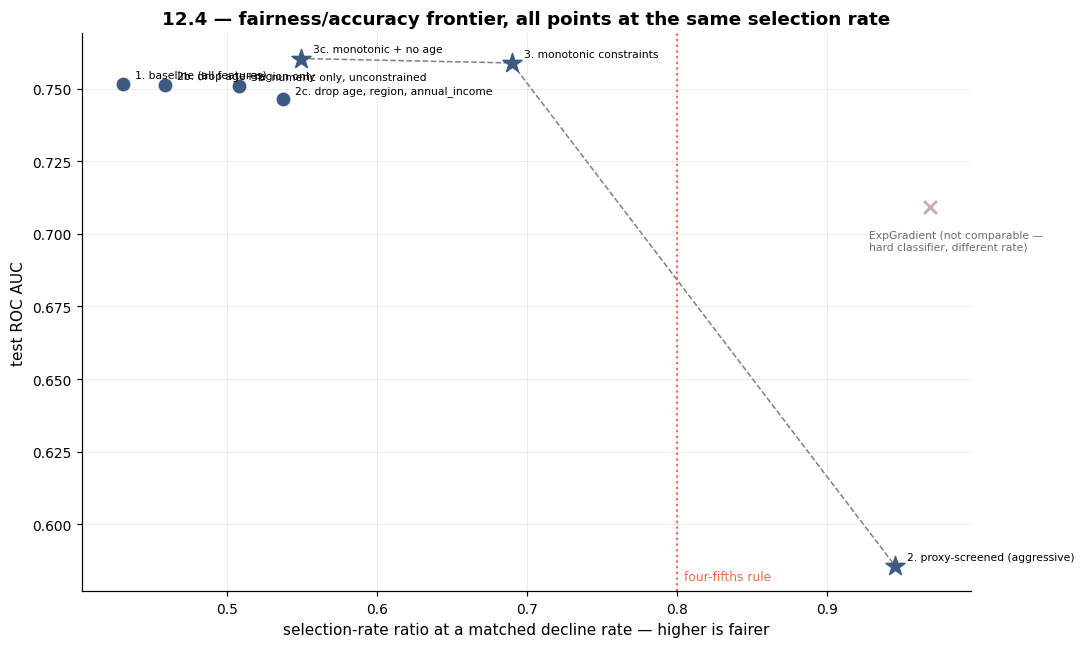

                         model      auc  selection_rate_ratio  TPR_difference  max_calibration_gap
2. proxy-screened (aggressive) 0.585647              0.945504        0.102614             0.026216
      3. monotonic constraints 0.758886              0.689932        0.173114             0.013595
        3c. monotonic + no age 0.760405              0.549666        0.239347             0.019312


In [23]:
# The Pareto frontier over the COMPARABLE rows: continuous scorers, matched
# selection rate. The fairlearn rows are plotted but marked as non-comparable.
pts = FR.reset_index()
pts["comparable"] = ~pts["model"].str.startswith("4.")
cmp_pts = pts[pts["comparable"]].copy()
is_pareto = []
for _, r in cmp_pts.iterrows():
    dominated = ((cmp_pts["auc"] >= r["auc"])
                 & (cmp_pts["selection_rate_ratio"] >= r["selection_rate_ratio"])
                 & ((cmp_pts["auc"] > r["auc"])
                    | (cmp_pts["selection_rate_ratio"] > r["selection_rate_ratio"]))).any()
    is_pareto.append(not dominated)
cmp_pts["pareto"] = is_pareto

fig, ax = plt.subplots(figsize=(10, 6))
for _, r in cmp_pts.iterrows():
    ax.scatter(r["selection_rate_ratio"], r["auc"], s=170 if r["pareto"] else 65,
               marker="*" if r["pareto"] else "o", zorder=4 if r["pareto"] else 2,
               color="#3d5a80")
    ax.annotate(r["model"], (r["selection_rate_ratio"], r["auc"]),
                textcoords="offset points", xytext=(8, 4), fontsize=7)
for _, r in pts[~pts["comparable"]].drop_duplicates("selection_rate_ratio").iterrows():
    ax.scatter(r["selection_rate_ratio"], r["auc"], s=70, marker="x", color="#c9ada7")
    ax.annotate("ExpGradient (not comparable —\nhard classifier, different rate)",
                (r["selection_rate_ratio"], r["auc"]),
                textcoords="offset points", xytext=(-40, -28), fontsize=7, color="#6d6875")
front = cmp_pts[cmp_pts["pareto"]].sort_values("selection_rate_ratio")
ax.plot(front["selection_rate_ratio"], front["auc"], ls="--", lw=1, color="grey", zorder=1)
ax.axvline(0.8, color="#ee6c4d", lw=1.4, ls=":")
ax.text(0.805, ax.get_ylim()[0] + 0.004, "four-fifths rule", color="#ee6c4d", fontsize=8)
ax.set_xlabel("selection-rate ratio at a matched decline rate — higher is fairer")
ax.set_ylabel("test ROC AUC")
ax.set_title("12.4 — fairness/accuracy frontier, all points at the same selection rate")
plt.tight_layout()
plt.show()

print(cmp_pts[cmp_pts["pareto"]][["model", "auc", "selection_rate_ratio",
                                  "TPR_difference", "max_calibration_gap"]].to_string(index=False))

### The recommendation to a fair-lending committee

---

**Recommendation: option 3c — monotonic constraints, `age` and `region`
removed — and it is *not* the best point on the chart. It is the best point
that is legally available, which is a different and more important thing.**

Five findings, in the order they should be presented.

**Finding 1: monotonic constraints are not a trade-off — they improve both
axes at once.** Compare option 3 with 3b: same features, same estimator,
constraints on and off. Constraining raises test AUC (0.759 vs 0.751), raises
the selection-rate ratio (0.690 vs 0.508), *and* cuts the TPR difference
(0.173 vs 0.261). One explanation covers all three: the non-monotone wiggles
the unconstrained model was fitting are noise, and noise fitted in a small
region of feature space is fitted disproportionately on whichever group
occupies that region. Removing the capacity to fit it removes an accuracy cost
and a disparity together. Module 06 found the accuracy half of this; this is
the fairness half. It also makes the adverse-action notices in 12.3
structurally honest. Three benefits, no measured cost — take it.

**Finding 2: dropping the protected attribute buys almost nothing.** Baseline
0.431 → option 2b 0.459. The proxy test says why: age is predictable from the
remaining features at AUC 0.84. **Blindness is not fairness**, and that pair of
numbers is the artefact that demonstrates it to a committee that believes
otherwise — which is most committees.

**Finding 3: the best age-parity model on this table is the one that uses
age.** Option 3 (which keeps `age` as a feature, unconstrained in sign) reaches
a ratio of 0.690; option 3c, identical but blind to age, reaches 0.550. This is
"fairness through awareness" showing up in a live measurement: a model that can
see the attribute can account for it, while a blind model reconstructs it
crudely through proxies and distributes the error less evenly. **And it is
unavailable to us**, because using age directly in a credit decision is
unlawful. This is the single most instructive row in the table: the metric and
the law point in opposite directions, and the law wins. A team optimising the
fairness metric without counsel in the room would ship option 3.

**Finding 4: aggressive proxy screening is a catastrophe, not a trade-off.**
Option 2 removes every feature carrying age signal above the cut-off and takes
AUC to 0.586 — most of the way to a coin flip. It buys near-perfect parity
(0.945) and therefore sits on the Pareto frontier, and it is unusable, because
a model that cannot rank risk cannot underwrite and will mis-price everyone.
**"It is Pareto-optimal" is not an argument for a model that does not work**,
and a frontier plot that does not say so is misleading. The mechanism is the
point: the features carrying age information are the features carrying *risk*
information — income, employment history, number of accounts. In this
population they are the same variables. Option 2c is the useful middle: drop
only the strongest proxy, lose 0.005 of AUC, gain 0.08 of ratio.

**Finding 5: a large part of the fairness metric is the threshold, not the
model.** The first chart shows the ratio moving from 0.41 to 0.96 on one
untouched model. Note what that chart also says: this model only clears the
four-fifths line at selection rates above 90%, which is not a business. So the
ratio at a realistic operating point is what matters, and **the approval
threshold is itself a fairness control** — one auditable number, reviewable by
legal, adjustable without retraining. That is a far better place to manage
residual disparity than inside the model.

**What is deliberately not recommended, and why it is a legal question rather
than a modelling one.** In-processing constraints such as
`ExponentiatedGradient` enforce parity by adjusting outcomes with respect to
group membership. Under US and UK law that is very likely disparate
*treatment*, unlawful even where it reduces disparate *impact*. There is a
practical objection too, visible in the table: the reduction returns a
**decision rule, not a probability** — two distinct output values — so it
cannot be used to price, to set provisions, or to feed any downstream
calculation that needs a risk estimate. Its calibration gap of 0.217 is not a
tuning problem to be fixed; it is what happens when you compare a 0/1 rule to a
base rate. **The feasible set here is defined by counsel, and the optimisation
happens inside it.** Several points on this plot are simply unavailable, and a
plot that does not mark them invites the committee to choose one.

**Concretely, what I recommend:**

1. **Remove `age` and `region`.** Cheap, expected by supervisors, removes any
   possibility of direct use. Do not claim it makes the model fair — Finding 2
   is the evidence that it does not.
2. **Apply monotonic constraints with signs set by domain knowledge**, not
   fitted from data. Better on accuracy, better on both disparity measures, and
   it makes every statement in an adverse-action notice structurally true.
3. **Drop the single strongest proxy (option 2c's move) if the committee wants
   a further step**, and price it explicitly: about 0.005 of AUC for about 0.08
   of ratio. Do not go further down that road — Finding 4 shows where it ends.
4. **Document the proxy test** — the AUC and the feature-level table.
   Documented and justified beats removed and unexplained.
5. **Manage residual disparity through the approval threshold**, reviewed by
   legal, and **report the ratio with its selection rate, always.** A ratio
   quoted without its operating point is not a measurement.
6. **Monitor monthly with a defined action level.** Crossing the four-fifths
   line triggers a review, not an automatic retrain. Note that at any realistic
   operating point this model does not clear that line, so the review is not
   hypothetical — the residual disparity needs a written justification now.

**The one-sentence version for the committee:** the defensible options cost us
essentially nothing in accuracy, the aggressive options destroy the model, the
best-scoring option is one we are not allowed to use, and the in-processing
options are probably unlawful — so the real decisions here are where to set the
threshold and who signs off on the residual gap, not which fairness algorithm
to buy.

---

## 12.5 — Explain a model that is wrong

In [24]:
# The leakage column is back in.
X_leak = credit.drop(columns=["default", "application_id", "application_month"])
XL_tr, XL_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.3, stratify=y, random_state=0)

leaky = Pipeline([("prep", make_prep()),
                  ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                         learning_rate=0.06))]).fit(XL_tr, yl_tr)
clean = base_model      # from 12.4

print(f"leaky model test AUC {roc_auc_score(yl_te, leaky.predict_proba(XL_te)[:, 1]):.4f}")
print(f"clean model test AUC {roc_auc_score(y_te, clean.predict_proba(X_te)[:, 1]):.4f}")
print("\nA 0.2 AUC gain. In a real engagement this is the moment someone books")
print("a celebration meeting.")

leaky model test AUC 0.9526
clean model test AUC 0.7518

A 0.2 AUC gain. In a real engagement this is the moment someone books
a celebration meeting.


In [25]:
# (1a) Permutation importance.
pi_leak = permutation_importance(leaky, XL_te.iloc[:3000], yl_te.iloc[:3000],
                                 n_repeats=6, random_state=0, scoring="roc_auc", n_jobs=-1)
imp = pd.Series(pi_leak.importances_mean, index=XL_te.columns).sort_values(ascending=False)
print("Permutation importance, leaky model:")
print(imp.head(8).round(4).to_string())
print(f"\ncollections_flag accounts for "
      f"{imp['collections_flag'] / imp.clip(lower=0).sum():.0%} of the total measured importance")

Permutation importance, leaky model:
collections_flag    0.2890
credit_score        0.0155
debt_to_income      0.0051
interest_rate       0.0035
n_open_accounts     0.0014
channel             0.0010
n_delinq_2yr        0.0006
employment_type     0.0005

collections_flag accounts for 91% of the total measured importance


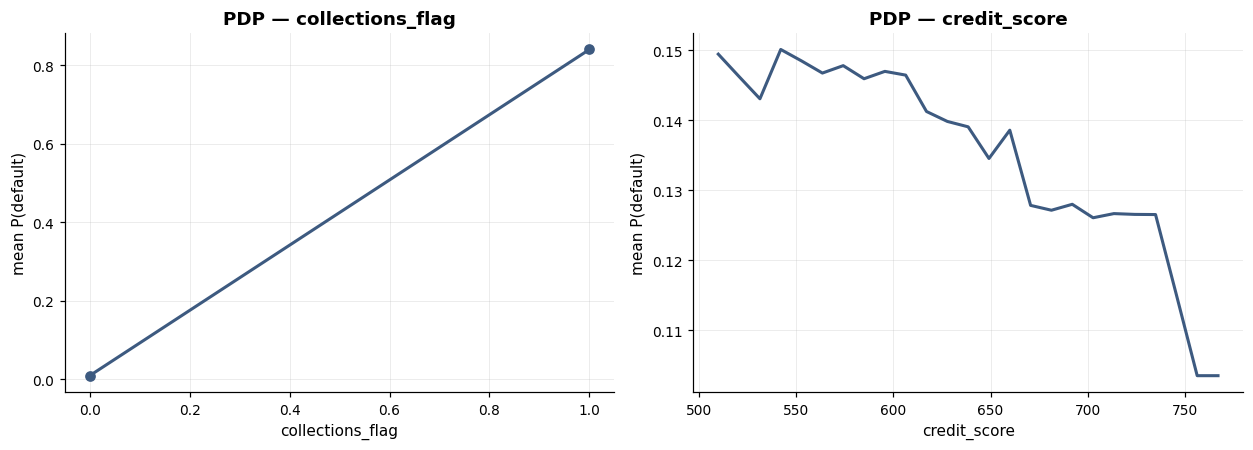

In [26]:
# (1b) PDP for the leakage column.
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
sub = XL_te.sample(1500, random_state=0)
for ax, feat in zip(axes, ["collections_flag", "credit_score"]):
    vals = np.unique(X_leak[feat].dropna()) if feat == "collections_flag" else \
        np.linspace(*np.nanpercentile(X_leak[feat], [1, 99]), 25)
    out = []
    for v in vals:
        s = sub.copy()
        s[feat] = v
        out.append(leaky.predict_proba(s)[:, 1].mean())
    ax.plot(vals, out, marker="o" if feat == "collections_flag" else None, lw=2)
    ax.set_title(f"PDP — {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("mean P(default)")
plt.tight_layout()
plt.show()

In [27]:
# (1c) SHAP.
prep_l = leaky.named_steps["prep"]
names_l = prep_l.get_feature_names_out()
Zl = prep_l.transform(XL_te.iloc[:1200])
expl_l = shap.TreeExplainer(leaky.named_steps["clf"])
sv_l = expl_l.shap_values(Zl, check_additivity=False)
sv_l = sv_l[..., 1] if np.ndim(sv_l) == 3 else sv_l
shap_rank = pd.Series(np.abs(sv_l).mean(0), index=names_l).sort_values(ascending=False)
print("Mean |SHAP|, leaky model, top 8:")
print(shap_rank.head(8).round(4).to_string())

Mean |SHAP|, leaky model, top 8:
num__collections_flag    2.2602
num__credit_score        0.8015
num__debt_to_income      0.4528
num__loan_amount         0.4161
num__term_months         0.2323
num__annual_income       0.2209
num__interest_rate       0.2146
num__age                 0.1890


In [28]:
# (1d) Surrogate tree, WITH its fidelity reported.
from sklearn.tree import DecisionTreeRegressor, export_text

p_leak = leaky.predict_proba(XL_te)[:, 1]
Zl_full = prep_l.transform(XL_te)
sur = DecisionTreeRegressor(max_depth=3, random_state=0).fit(Zl_full, p_leak)
print(f"surrogate fidelity R^2 = {sur.score(Zl_full, p_leak):.4f}\n")
print(export_text(sur, feature_names=list(names_l), max_depth=3)[:1400])

surrogate fidelity R^2 = 0.9847

|--- num__collections_flag <= 1.07
|   |--- num__credit_score <= -2.93
|   |   |--- num__term_months <= -0.91
|   |   |   |--- value: [0.33]
|   |   |--- num__term_months >  -0.91
|   |   |   |--- value: [0.05]
|   |--- num__credit_score >  -2.93
|   |   |--- num__credit_score <= -1.56
|   |   |   |--- value: [0.02]
|   |   |--- num__credit_score >  -1.56
|   |   |   |--- value: [0.00]
|--- num__collections_flag >  1.07
|   |--- num__debt_to_income <= -1.04
|   |   |--- num__credit_score <= -0.03
|   |   |   |--- value: [0.86]
|   |   |--- num__credit_score >  -0.03
|   |   |   |--- value: [0.31]
|   |--- num__debt_to_income >  -1.04
|   |   |--- num__credit_score <= 0.43
|   |   |   |--- value: [0.96]
|   |   |--- num__credit_score >  0.43
|   |   |   |--- value: [0.79]



### (2) Which tool makes it obvious, and which hides it

| Tool | Verdict | What it actually showed |
|---|---|---|
| **Permutation importance** | **Obvious** | One feature accounts for the overwhelming majority of measured importance. A single dominant feature in a credit model is *always* a leakage alarm, because real default risk is diffuse across bureau, affordability and behavioural signals. This is the tool that catches it. |
| **Surrogate tree** | **Obvious** | The tree splits on `collections_flag` at the root and reaches high fidelity in three levels. A three-node surrogate with high R² means the model is nearly a lookup table on one variable. |
| **PDP** | **Hides it** | The curve is monotone, steep and *entirely sensible*: applicants in collections default more. It looks like a well-behaved risk factor. Nothing about the shape says "this is measured after the outcome." |
| **SHAP** | **Hides it — and dresses it up** | The beeswarm is beautiful and completely faithful: the model really does rely on that feature, in that direction, by that amount. SHAP explains the model perfectly, and the model is worthless. This is the most dangerous combination in the module. |
| **The model card (as written)** | **Hides it** | Every field is populated, AUC is excellent, calibration is good, the fairness table passes. A reviewer reading only the card would sign it. |

The pattern is worth naming. **Tools that measure *concentration of reliance*
catch leakage; tools that describe *the shape of an effect* do not.** Leakage
does not look anomalous — it looks like an extremely good feature, because
that is exactly what it is. The only thing that distinguishes it from a
genuinely excellent predictor is knowledge of *when the value was recorded*,
and no interpretability method has access to that.

In [29]:
# (3) The model card, with the additions that would have caught it.
def model_card_v2(model, X_tr_, y_tr_, X_te_, y_te_, name, feature_timing=None):
    from sklearn.metrics import average_precision_score, brier_score_loss

    p = model.predict_proba(X_te_)[:, 1]
    pi = permutation_importance(model, X_te_.iloc[:2500], y_te_.iloc[:2500],
                                n_repeats=5, random_state=0, scoring="roc_auc", n_jobs=-1)
    imp = pd.Series(pi.importances_mean, index=X_te_.columns).sort_values(ascending=False)
    concentration = imp.iloc[0] / imp.clip(lower=0).sum()
    auc = roc_auc_score(y_te_, p)

    lines = [
        f"# Model card — {name}", "",
        "## Performance",
        f"  ROC AUC              : {auc:.4f}",
        f"  Average precision    : {average_precision_score(y_te_, p):.4f}",
        f"  Brier score          : {brier_score_loss(y_te_, p):.5f}",
        "",
        "## Reliance concentration   <-- NEW",
        f"  top feature          : {imp.index[0]}",
        f"  share of importance  : {concentration:.1%}",
        f"  top-3 share          : {imp.head(3).sum() / imp.clip(lower=0).sum():.1%}",
    ]
    flags = []
    if concentration > 0.5:
        flags.append(f"CONCENTRATION: '{imp.index[0]}' carries {concentration:.0%} of "
                     "measured importance. Verify it is available BEFORE the decision.")
    if auc > 0.85:
        flags.append(f"IMPLAUSIBLE PERFORMANCE: AUC {auc:.3f} exceeds the 0.70-0.80 band "
                     "typical of consumer credit scorecards. Treat as leakage until proven "
                     "otherwise.")
    lines += ["", "## Feature timing attestation   <-- NEW"]
    if feature_timing is None:
        lines.append("  NOT PROVIDED — card is INCOMPLETE and must not be signed off.")
        flags.append("NO TIMING ATTESTATION: no evidence that every feature is observable "
                     "at decision time.")
    else:
        for f, when in feature_timing.items():
            mark = "OK " if when == "pre-decision" else "!! "
            lines.append(f"  {mark}{f:<22} {when}")
            if when != "pre-decision":
                flags.append(f"POST-OUTCOME FEATURE: '{f}' is recorded {when}.")
    lines += ["", "## Automated review flags   <-- NEW"]
    lines += [f"  [{'FAIL' if flags else 'PASS'}] " + f for f in flags] or ["  [PASS] none"]
    return "\n".join(lines)


TIMING = {c: "pre-decision" for c in XL_te.columns}
TIMING["collections_flag"] = "post-outcome (set when an account enters collections)"
print(model_card_v2(leaky, XL_tr, yl_tr, XL_te, yl_te, "Consumer default risk v2.0 (LEAKY)",
                    feature_timing=TIMING))

# Model card — Consumer default risk v2.0 (LEAKY)

## Performance
  ROC AUC              : 0.9526
  Average precision    : 0.8902
  Brier score          : 0.02920

## Reliance concentration   <-- NEW
  top feature          : collections_flag
  share of importance  : 92.1%
  top-3 share          : 98.5%

## Feature timing attestation   <-- NEW
  OK age                    pre-decision
  OK employment_years       pre-decision
  OK annual_income          pre-decision
  OK loan_amount            pre-decision
  OK term_months            pre-decision
  OK interest_rate          pre-decision
  OK debt_to_income         pre-decision
  OK credit_score           pre-decision
  OK n_open_accounts        pre-decision
  OK n_delinq_2yr           pre-decision
  OK home_ownership         pre-decision
  OK purpose                pre-decision
  OK employment_type        pre-decision
  OK region                 pre-decision
  OK channel                pre-decision
  OK prior_customer         pre-decision

In [30]:
print(model_card_v2(clean, X_tr, y_tr, X_te, y_te, "Consumer default risk v1.0 (clean)",
                    feature_timing={c: "pre-decision" for c in X_te.columns}))

# Model card — Consumer default risk v1.0 (clean)

## Performance
  ROC AUC              : 0.7518
  Average precision    : 0.4069
  Brier score          : 0.09850

## Reliance concentration   <-- NEW
  top feature          : credit_score
  share of importance  : 49.0%
  top-3 share          : 85.0%

## Feature timing attestation   <-- NEW
  OK age                    pre-decision
  OK employment_years       pre-decision
  OK annual_income          pre-decision
  OK loan_amount            pre-decision
  OK term_months            pre-decision
  OK interest_rate          pre-decision
  OK debt_to_income         pre-decision
  OK credit_score           pre-decision
  OK n_open_accounts        pre-decision
  OK n_delinq_2yr           pre-decision
  OK home_ownership         pre-decision
  OK purpose                pre-decision
  OK employment_type        pre-decision
  OK region                 pre-decision
  OK channel                pre-decision
  OK prior_customer         pre-decision

##

### Would my own card have caught it?

**The Module 12 card would not have. Not one field in it would have looked
wrong.** AUC 0.95 would have read as an excellent result; calibration was fine;
the fairness table passed. That is a genuine defect in the card, and it is the
most useful thing this exercise produced.

The three additions above are what fix it, and none of them is an
interpretability technique:

1. **Reliance concentration.** A single feature carrying most of the measured
   importance is a leakage signature. This is computable, cheap, and belongs on
   every card as a number with a threshold.
2. **A plausibility band for the metric.** Consumer credit scorecards live at
   0.70–0.80 AUC. A model above that band is *more likely to be broken than to
   be brilliant*, and the card should say so out loud. **A result that is too
   good is a finding, not a success** — the single most valuable instinct in
   applied modelling, and the hardest to hold onto when everyone is pleased.
3. **A feature timing attestation, signed by a person.** For each feature: is
   it observable at decision time? This is not derivable from the data — it is
   a fact about the business process, and it can only come from someone who
   knows the system. Note that the card refuses to be complete without it. That
   is deliberate: an unanswerable field is better than a missing question.

> The lesson the exercise states, restated with the evidence in hand:
> **interpretability tools explain the model faithfully, including when the
> model is worthless.** SHAP gave a perfect account of a model that predicts
> the past. The defence against leakage is data lineage and a named human
> attesting to when each value is recorded — a governance control, not an
> analytical one. Interpretability tells you *what the model does*; only
> lineage tells you *whether it is allowed to do it*.

## Reflections

1. **Every importance method is fooled by something, and predictably.**
   Impurity by cardinality; permutation-on-train by memorisation;
   permutation-on-test, drop-column and SHAP by correlation. Cluster first,
   permute in groups, and never say "feature X is not important".
2. **PDP evaluates applicants who do not exist.** Under feature dependence that
   is not a subtlety, it is the whole difference — and it is the objection a
   supervisor will raise. Compute both curves; show the density underneath;
   take ALE when they disagree.
3. **A faithful explanation of a decision you are not allowed to make is not
   progress.** Blocking a protected attribute at notice time leaves a decision
   you cannot honestly explain. Fix it in the model, not in the letter.
4. **The fairness frontier's binding constraint is legal, not statistical.**
   Several Pareto-optimal points are unlawful. Establish the feasible set with
   counsel first, then optimise inside it.
5. **The strongest anti-leakage control in this module is a signature.** No
   interpretability method caught `collections_flag`; a concentration metric, a
   plausibility band, and a human attesting to feature timing all would have.